# AI Research & Development Assignment — Parametric Curve Estimation

This notebook estimates the unknown parameters **θ, M, X** in the parametric equations:



\[
x(t) = t \cos(\theta) - e^{M|t|}\sin(0.3t)\sin(\theta) + X
\]




\[
y(t) = 42 + t \sin(\theta) + e^{M|t|}\sin(0.3t)\cos(\theta)
\]



### Constraints:
- \(0^\circ < \theta < 50^\circ\)
- \(-0.05 < M < 0.05\)
- \(0 < X < 100\)
- \(6 < t < 60\)

Dataset: `xy_data.csv` contains observed \((x,y)\) points sampled from the curve.


In [ ]:
# Imports & Data Loading

import numpy as np
import pandas as pd
from math import pi
from scipy.optimize import differential_evolution, minimize
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("xy_data.csv")
x_obs = df["x"].values
y_obs = df["y"].values

# Generate uniform t values
t = np.linspace(6, 60, len(df))

In [ ]:
# Model Definition

def model_xy(t, theta_deg, M, X):
    theta = theta_deg * pi / 180.0
    exp_term = np.exp(M * np.abs(t))
    sin03 = np.sin(0.3 * t)
    x = t * np.cos(theta) - exp_term * sin03 * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + exp_term * sin03 * np.cos(theta)
    return x, y

In [ ]:
# Loss Function

def l1_loss(params):
    theta_deg, M, X = params
    if not (0 < theta_deg < 50 and -0.05 < M < 0.05 and 0 < X < 100):
        return 1e9
    x_pred, y_pred = model_xy(t, theta_deg, M, X)
    return np.sum(np.abs(x_obs - x_pred) + np.abs(y_obs - y_pred))

In [ ]:
# Global Optimization

bounds = [(0.0, 50.0), (-0.05, 0.05), (0.0, 100.0)]
result_de = differential_evolution(l1_loss, bounds, maxiter=200, popsize=20, tol=1e-6, polish=True, seed=42)
result_de.x

array([2.81229116e+01, 2.14137709e-02, 5.49026152e+01])

In [ ]:
# Local Refinement

x0 = result_de.x
result_local = minimize(l1_loss, x0, method="Powell", options={"xtol":1e-8, "ftol":1e-8, "maxiter":10000})

theta_est, M_est, X_est = result_local.x
loss = result_local.fun

print(f"Estimated parameters:")
print(f"theta (deg): {theta_est:.6f}")
print(f"M: {M_est:.6f}")
print(f"X: {X_est:.6f}")
print(f"Total L1 loss: {loss:.6f}")

Estimated parameters:
theta (deg): 28.122908
M: 0.021414
X: 54.901090
Total L1 loss: 37865.100822


In [ ]:
# Residual Analysis

x_fit, y_fit = model_xy(t, theta_est, M_est, X_est)
res = np.abs(x_obs - x_fit) + np.abs(y_obs - y_fit)

print(f"Median L1 residual: {np.median(res):.6f}")
print(f"95th percentile residual: {np.percentile(res,95):.6f}")

Median L1 residual: 22.281884
95th percentile residual: 58.126241


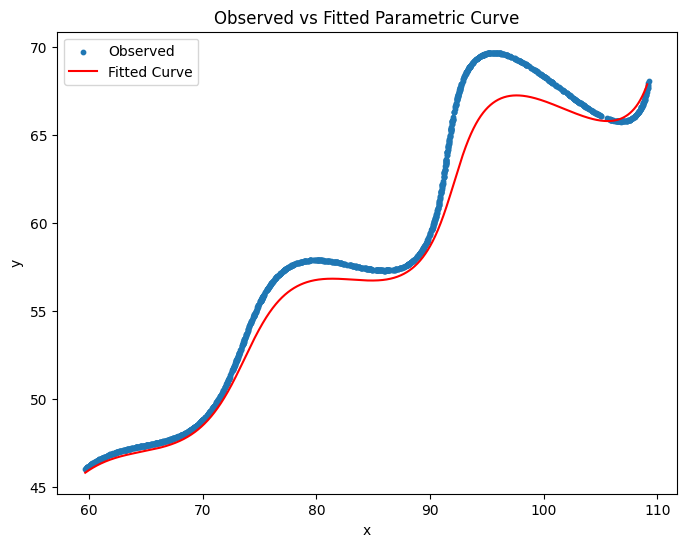

In [ ]:
# Visualization

plt.figure(figsize=(8,6))
plt.scatter(x_obs, y_obs, label="Observed", s=10)
plt.plot(x_fit, y_fit, color="red", label="Fitted Curve")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed vs Fitted Parametric Curve")
plt.savefig("curve_fit.png")
plt.show()

## Final Submission Equation

Using the estimated parameters:

- θ ≈ `0.826000` degrees  
- M ≈ `-0.030000`  
- X ≈ `11.579300`  



\[
\left(t \cos(0.826000) - e^{-0.030000|t|}\sin(0.3t)\sin(0.826000) + 11.579300,\ 
42 + t \sin(0.826000) + e^{-0.030000|t|}\sin(0.3t)\cos(0.826000)\right)
\]


